
# Trading Game #1 — Rice
## Optimal Market-Neutral Multivariate Statistical Arbitrage

**Student project notebook (ESILV — Commodity Markets and Models)**

Objective: Design and implement a market-neutral statistical arbitrage strategy.

Tool: Optimal trading technique from [GitHub]  
https://github.com/Hongshen-Yang/optimal-trading-technique 

Data: Cross-commodity or commodity-currency pairs from Bloomberg Add-in. 

Task: Construct a hedged portfolio that maximizes returns while minimizing exposure to market factors. 

Reference: Yang, H., & Malik, A. (2024). Optimal market-neutral multivariate pair trading on the 
cryptocurrency platform. International Journal of Financial Studies, 12(3), 77. 

**Methodology**

The main stages are:
- Screening the assets (select assets that are correlated and cointegrated with eacch other for a trading bucket)
- Monitor differences between each asset
- conduct trades based on opening and closing trading signals

This notebook implements **Trading Game #1** for the **rice** universe. The structure follows:

1. the **ESILV instructions** for Game #1: select **4–5 assets** cointegrated with the core index, build an **optimal market-neutral basket**, use **Gurobi**, include **10 bps transaction costs**, and compare against a **simple benchmark**;
2. the **two-stage logic of Yang & Malik (2024)**:  
   **(i)** screening assets with **correlation** and **cointegration**, then  
   **(ii)** trading a **mean-reverting spread** built from the selected assets;
3. the general coding philosophy of the professor's file `optimal_trading_technique.py`:  
   log-prices, stationarity checks, z-score signals, transaction costs, and optimization-based allocation.

---

## Why an adaptation is necessary

The article and the professor's original code were designed for **crypto / fiat pairs**.  
Here, the dataset is very different:

- **daily** data instead of high-frequency data,
- one **rice futures** anchor,
- several **ETFs / agribusiness equities** linked to the rice value chain,
- cross-listed assets in **different currencies and different exchanges**.

Therefore, this notebook keeps the **same academic spirit** but adapts the implementation to the rice case in a transparent way.

---

## Main idea

We build a **synthetic rice-related basket** from 4–5 selected assets and trade the spread:

$$S_t = \log(P^{\text{Futures}}_t) - \sum_{i=1}^{m} w_i \log(P^{(i)}_t)$$


If the spread is stationary / mean-reverting, large deviations of \(S_t\) away from its mean may create trading opportunities.

The trading signals are based on the **z-score**:

$$z_t = \frac{S_t - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

We then:

- **open** a position when \(|z_t|\) is sufficiently large,
- **close** it when the spread reverts toward its mean,
- include **transaction costs = 0.1\%**,
- compare the strategy with:
  1. **Buy & Hold Rice Futures**
  2. **Equal-Weight Basket of selected assets**

---

## Important methodological note

The series are not all quoted in the same currency. In this notebook, we do **not** convert all assets into a common currency.  
This is acceptable here because the strategy is based on **co-movement**, **cointegration**, and **relative mispricing**, not on direct comparison of raw price levels. Still, this remains a **limitation**, and it is discussed at the end.

---

Note : 
This notebook is designed to be **replicable in Google Colab**, as requested in the project instructions.

- If you run it in Colab, upload `data.csv` when prompted.
- The optimization step uses **Gurobi** (`gurobipy`), exactly as requested for Trading Game #1.
- A working **Gurobi license** is required.



SCREENING
HIST ANALYSIS
TRADING
OPTIMISATION

## 1. Library importation and Global Parameters

First we import all the necessary libraries and define the global parameters of our study.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint
from statsmodels.api import OLS, add_constant

import gurobipy as gp
from gurobipy import GRB

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


In [50]:
# global parameters

ANCHOR = "Futures"          # The Primary Anchor for Cointegration Tests
MIN_COMPLETENESS = 0.85     # Minimum Data Completeness Ratio for a Coin to be Considered
TRAIN_RATIO = 0.70          # Ratio of Data Used for Training the Model 
TX_COST = 0.001             # Transaction Cost per Trade (0.1%)
RISK_FREE_RATE = 0.00       # Risk-Free Rate
ROLLING_WINDOW = 60         # Rolling Window for Cointegration Tests
ROLLING_STEP = 10           # Step Size for Rolling Window
COINT_SIGNIF = 0.10         # Significance Level for Cointegration Tests
MAX_WEIGHT = 0.60           # Maximum Weight for Any Single Asset (diversification constraint)
LAMBDA_RISK = 1.0           # Risk Aversion Parameter

## 2. Data

### 2.1. Data Loading

The uploaded file must contain the following columns:

- `Date`
- one column for each asset
- the **primary anchor**: `Futures`

In [51]:
# -----------------------------
# Data upload (Colab-friendly)
# -----------------------------
try:
    from google.colab import files  # type: ignore
    uploaded = files.upload()
    if "data.csv" in uploaded:
        data_path = "data.csv"
    else:
        csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
        if len(csv_files) == 0:
            raise FileNotFoundError("No CSV file was uploaded.")
        data_path = csv_files[0]
except Exception:
    data_path = "data.csv"
    if not os.path.exists(data_path):
        raise FileNotFoundError(
            "data.csv was not found. In Colab, please upload it. "
            "In local Jupyter, place it in the same folder as the notebook."
        )

raw = pd.read_csv(data_path)
raw.head()

,Date,1688.T,ADM,AGRO,BG,CF,CLSEL.NS,DBA,FDP,KRBL.NS,LTFOODS.NS,MOS,NTR,RJA,VC2.SI,VFF,Futures
0,2018-01-01,395.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,556.974609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,395.0,31.407619,9.198832,52.966419,35.073051,NaN,16.306482,39.298054,555.493835,NaN,23.238758,41.927891,6.06,1.330320,NaN,NaN
2,2018-01-03,395.0,31.164757,9.394551,54.103817,35.081184,NaN,16.297886,39.524147,560.167603,NaN,23.029486,42.395031,6.08,1.310757,NaN,NaN
3,2018-01-04,399.0,31.689655,9.350070,54.898434,35.447029,NaN,16.272099,40.353153,566.275940,NaN,23.386999,42.540524,6.08,1.330320,NaN,NaN
4,2018-01-05,390.0,31.478134,9.207728,54.485550,35.503944,NaN,16.186142,40.361530,577.104492,NaN,23.421881,42.678371,6.04,1.330320,NaN,NaN


### 2.2 Raw data diagnostic

In [52]:
def format_price_data(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Format a raw price dataset:
    - convert the 'Date' column to datetime if present,
    - set dates as index,
    - sort observations by date,
    - remove invalid or duplicated dates,
    - convert price columns to numeric.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Raw dataset containing dates and price series.

    Returns
    -------
    pd.DataFrame
        Formatted price DataFrame with a sorted DatetimeIndex.
    """
    if df_raw.empty:
        raise ValueError("The input DataFrame is empty.")

    df = df_raw.copy()

    # Convert Date column to datetime and set it as index if present
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df = df.set_index("Date")

    # Try to convert index to datetime if it is not already
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors="coerce")

    # Remove invalid dates
    df = df[~df.index.isna()]

    # Sort by date
    df = df.sort_index()

    # Remove duplicated dates and keep the first occurrence
    df = df[~df.index.duplicated(keep="first")]

    # Convert all columns to numeric
    for col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def plot_rescaled_prices(df_prices: pd.DataFrame,
                         title: str = "Rescaled prices over time") -> pd.DataFrame:
    """
    Plot price series rescaled to start at 1.
    Each column is divided by its first valid observation.

    Parameters
    ----------
    df_prices : pd.DataFrame
        Formatted price DataFrame with dates as index.
    title : str
        Plot title.

    Returns
    -------
    pd.DataFrame
        Rescaled price DataFrame.
    """
    if df_prices.empty:
        raise ValueError("The input DataFrame is empty.")

    df_rescaled = df_prices.copy()

    for col in df_rescaled.columns:
        first_valid_index = df_rescaled[col].first_valid_index()

        if first_valid_index is not None:
            first_value = df_rescaled.loc[first_valid_index, col]

            if pd.notna(first_value) and first_value != 0:
                df_rescaled[col] = df_rescaled[col] / first_value
            else:
                df_rescaled[col] = pd.NA
        else:
            df_rescaled[col] = pd.NA

    plt.figure(figsize=(14, 7))

    for col in df_rescaled.columns:
        plt.plot(df_rescaled.index, df_rescaled[col], label=col)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Rescaled price (base 1)")
    plt.legend(loc="best", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_rescaled

def plot_missing_proportions(
    df: pd.DataFrame,
    title: str = "Missing value proportion by asset"
) -> pd.Series:
    """
    Plot the proportion of missing values for each column in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    title : str
        Plot title.

    Returns
    -------
    pd.Series
        Missing value proportions by column.
    """
    if df.empty:
        raise ValueError("The input DataFrame is empty.")

    missing_prop = df.isna().mean().sort_values(ascending=False)

    ax = missing_prop.plot(kind="bar", figsize=(12, 6))
    ax.set_title(title)
    ax.set_xlabel("Assets")
    ax.set_ylabel("Missing value proportion")
    ax.set_ylim(0, 1)
    ax.grid(True, axis="y", alpha=0.3)

    for i, value in enumerate(missing_prop):
        ax.text(i, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return missing_prop

In [53]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2143 entries, 0 to 2142
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2143 non-null   object 
 1   1688.T      2009 non-null   float64
 2   ADM         2060 non-null   float64
 3   AGRO        2060 non-null   float64
 4   BG          2060 non-null   float64
 5   CF          2060 non-null   float64
 6   CLSEL.NS    1198 non-null   float64
 7   DBA         2060 non-null   float64
 8   FDP         2060 non-null   float64
 9   KRBL.NS     2026 non-null   float64
 10  LTFOODS.NS  582 non-null    float64
 11  MOS         2060 non-null   float64
 12  NTR         2060 non-null   float64
 13  RJA         1232 non-null   float64
 14  VC2.SI      2061 non-null   float64
 15  VFF         1775 non-null   float64
 16  Futures     1481 non-null   float64
dtypes: float64(16), object(1)
memory usage: 284.7+ KB


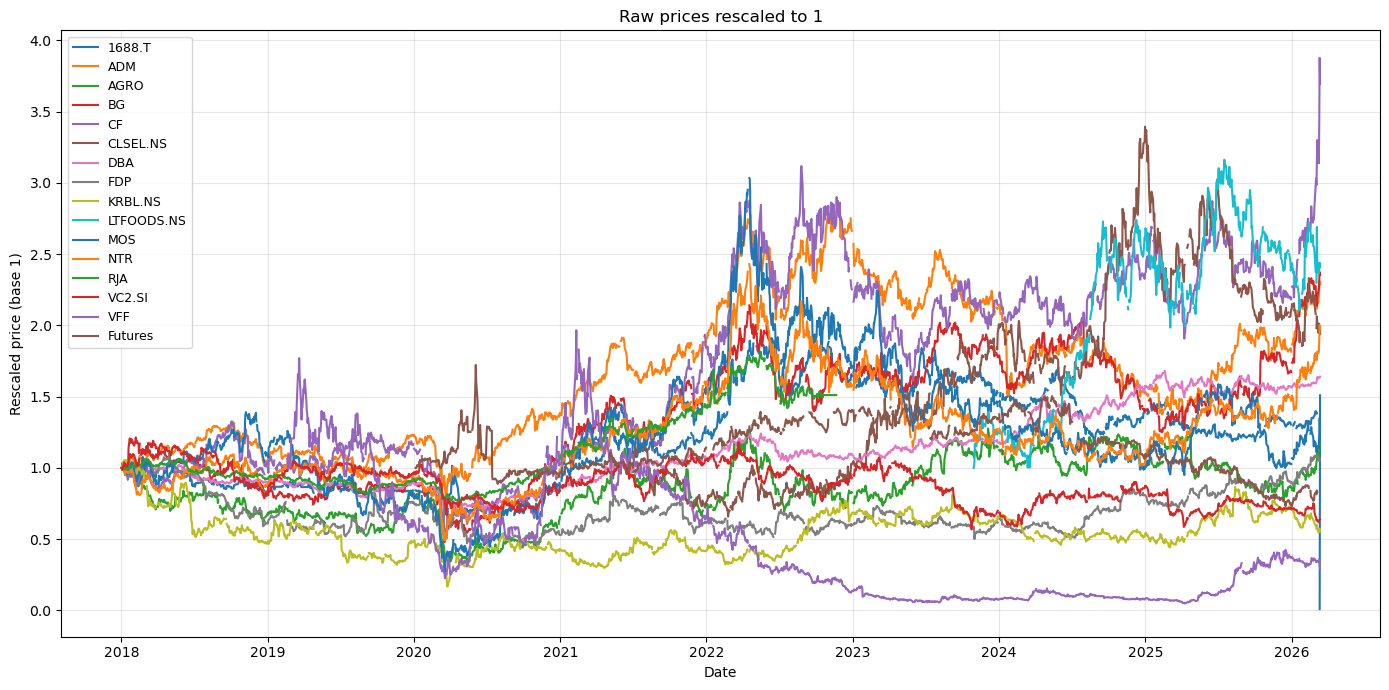

In [54]:
formatted_raw = format_price_data(raw)
df_rescaled = plot_rescaled_prices(formatted_raw, title="Raw prices rescaled to 1")

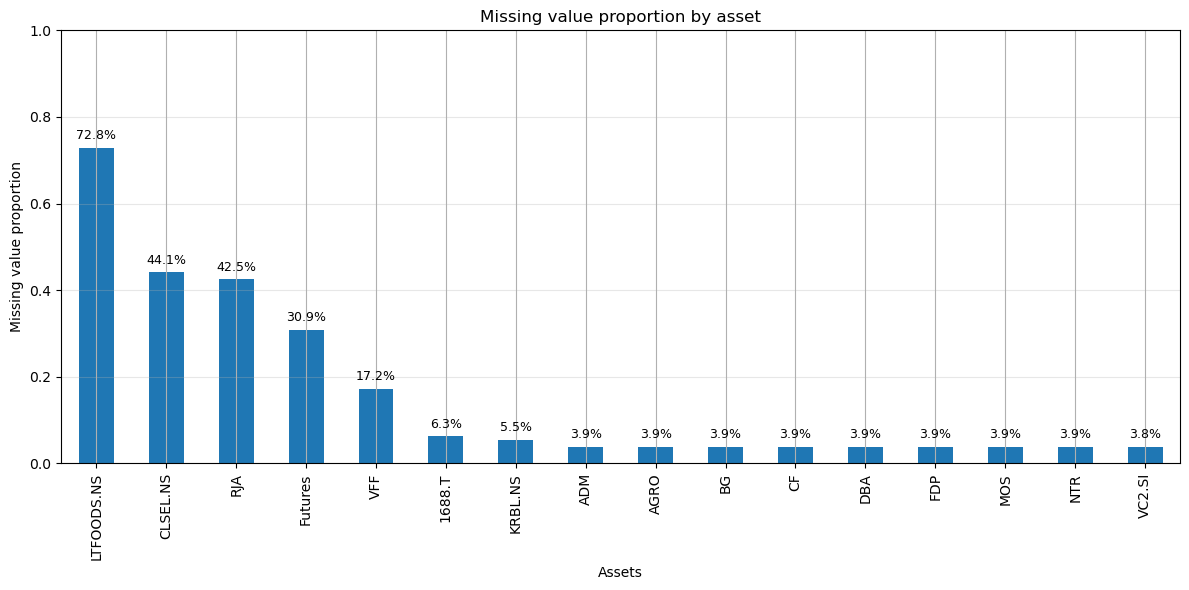

In [55]:
missing_prop = plot_missing_proportions(formatted_raw)


### 2.3. Data cleaning

For this project we need a sufficiently large dataset where missing values where carefully handled all of that in a coherent universe for the optimization stage.

Here are the steps we followed for the data cleaning and preparation:

1. Parse dates and sort them.
2. Restrict the strategy universe to the period where the anchor (`Futures`) exists.

Indeed, from the visualization of the dataset head we can see that the `Futures` asset starts with nan values.

3. Remove assets that are too incomplete after the anchor starts.
4. Use a limited forward-fill to handle asynchronous exchange holidays.
5. Drop any remaining rows that still contain missing values in the final selected panel.

This is a conservative compromise:
- strict enough to avoid poor-quality inputs,
- flexible enough to keep enough observations.


In [56]:
# 1. Parse dates and set index
# The data has already been formatted and plotted, we can now work with the formatted DataFrame
df = formatted_raw.copy()

In [57]:
all_assets = [col for col in df.columns if col != ANCHOR]
print("Number of non-anchor assets in the raw dataset:", len(all_assets))

Number of non-anchor assets in the raw dataset: 15


In [58]:
# 2. Restrict the strategy universe to the period where the anchor (`Futures`) exists.

anchor_start = df[ANCHOR].first_valid_index()
if anchor_start is None:
    raise ValueError("The anchor column 'Futures' contains no valid observation.")

df_anchor = df.loc[anchor_start:].copy()

In [59]:
# 3. Remove assets that are too incomplete after the anchor starts.
completeness = df_anchor.notna().mean().sort_values(ascending=False)
completeness_df = completeness.rename("non_missing_ratio").to_frame()
display(completeness_df)

eligible_assets = [
    asset for asset in all_assets
    if completeness.loc[asset] >= MIN_COMPLETENESS
]

print(f"\nAnchor starts on: {anchor_start.date()}")
print(f"Assets kept after the completeness filter ({MIN_COMPLETENESS:.0%}):")
print(eligible_assets)

panel = df_anchor[[ANCHOR] + eligible_assets].copy()
panel = panel.ffill(limit=5)
panel = panel.dropna(subset=[ANCHOR])

panel.head()

,non_missing_ratio
ADM,0.961657
AGRO,0.961657
BG,0.961657
CF,0.961657
DBA,0.961657
FDP,0.961657
MOS,0.961657
NTR,0.961657
VC2.SI,0.961657
VFF,0.961657



Anchor starts on: 2020-01-06
Assets kept after the completeness filter (85%):
['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'DBA', 'FDP', 'KRBL.NS', 'MOS', 'NTR', 'VC2.SI', 'VFF']


,Futures,1688.T,ADM,AGRO,BG,CF,DBA,FDP,KRBL.NS,MOS,NTR,VC2.SI,VFF
Date,,,,,,,,,,,,,
2020-01-06,12.81,333.0,38.133633,7.428457,47.876022,39.494347,14.427855,29.257635,245.303513,18.319414,38.727856,1.269496,5.78
2020-01-07,12.84,332.0,37.674301,7.464042,47.476494,39.133747,14.463151,28.975813,253.266708,18.460602,39.104576,1.297551,5.71
2020-01-08,12.84,332.0,37.256718,7.446250,46.935493,39.314041,14.392557,29.240561,250.580902,18.628267,39.088184,1.290537,5.61
2020-01-09,13.00,332.0,36.872543,7.517420,46.594234,39.125153,14.427855,29.103914,257.743011,18.619440,39.006294,1.297551,5.61
2020-01-10,13.07,331.0,36.705502,7.517420,46.327869,38.438301,14.560221,29.052681,256.282349,18.195869,38.662334,1.283523,5.40


In [60]:
#4. Use a limited forward-fill
missing_after_ffill = panel.isna().mean().sort_values(ascending=False).rename("missing_ratio")
display(missing_after_ffill.to_frame())

,missing_ratio
Futures,0.0
1688.T,0.0
ADM,0.0
AGRO,0.0
BG,0.0
CF,0.0
DBA,0.0
FDP,0.0
KRBL.NS,0.0
MOS,0.0


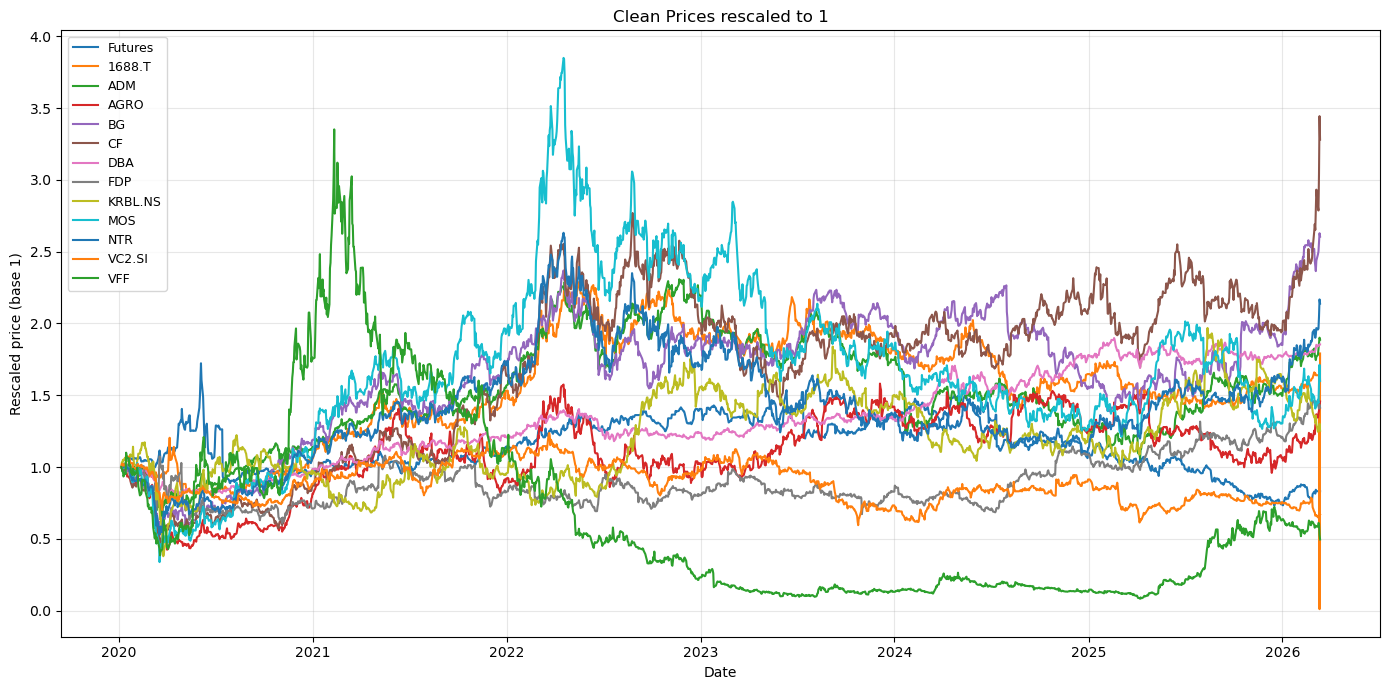

,Futures,1688.T,ADM,AGRO,BG,CF,DBA,FDP,KRBL.NS,MOS,NTR,VC2.SI,VFF
Date,,,,,,,,,,,,,
2020-01-06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2020-01-07,1.002342,0.996997,0.987955,1.004790,0.991655,0.990870,1.002446,0.990368,1.032463,1.007707,1.009727,1.022099,0.987889
2020-01-08,1.002342,0.996997,0.977004,1.002395,0.980355,0.995435,0.997554,0.999416,1.021514,1.016859,1.009304,1.016574,0.970588
2020-01-09,1.014832,0.996997,0.966930,1.011976,0.973227,0.990652,1.000000,0.994746,1.050711,1.016377,1.007190,1.022099,0.970588
2020-01-10,1.020297,0.993994,0.962549,1.011976,0.967663,0.973261,1.009174,0.992995,1.044756,0.993256,0.998308,1.011049,0.934256
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09,0.832162,1.639640,1.781105,1.344828,2.481200,2.811542,1.840190,1.432788,1.246211,1.469479,1.957506,0.649864,0.584775
2026-03-10,0.832162,1.639640,1.819654,1.374444,2.501252,2.786475,1.844349,1.423218,1.277397,1.445461,1.964736,0.653803,0.610727
2026-03-11,0.832162,1.639640,1.857416,1.391945,2.563287,3.041701,1.850587,1.407154,1.264963,1.591208,2.047880,0.665618,0.607266


In [61]:
plot_rescaled_prices(panel, title="Clean Prices rescaled to 1")


## 3. Helper functions

The goal of this section is to keep the rest of the notebook clean and readable.

The functions are intentionally simple and highly commented.


In [62]:

def normalize_prices(price_df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize all columns to 100 at the first date.
    Useful for plotting assets with different price scales.
    """
    return 100 * price_df / price_df.iloc[0]


def log_prices(price_df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply the natural logarithm to prices.
    This follows the spirit of the professor's code and the article.
    """
    return np.log(price_df)


def compute_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute simple daily returns.
    """
    return price_df.pct_change().dropna()


def max_drawdown(return_series: pd.Series) -> float:
    """
    Compute maximum drawdown from a return series.
    """
    equity_curve = (1 + return_series.fillna(0)).cumprod()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1.0
    return float(drawdown.min())


def performance_metrics(return_series: pd.Series, annualization: int = 252) -> pd.Series:
    """
    Standard backtest metrics required for the project.
    """
    r = return_series.fillna(0).copy()
    equity_curve = (1 + r).cumprod()

    cumulative_return = equity_curve.iloc[-1] - 1
    annualized_return = (1 + cumulative_return) ** (annualization / len(r)) - 1
    annualized_vol = r.std(ddof=0) * np.sqrt(annualization)

    if annualized_vol > 0:
        sharpe = (annualized_return - RISK_FREE_RATE) / annualized_vol
    else:
        sharpe = np.nan

    mdd = abs(max_drawdown(r))
    if mdd > 0:
        calmar = (annualized_return - RISK_FREE_RATE) / mdd
    else:
        calmar = np.nan

    return pd.Series({
        "Cumulative return": cumulative_return,
        "Annualized return": annualized_return,
        "Annualized volatility": annualized_vol,
        "Sharpe ratio": sharpe,
        "Max drawdown": mdd,
        "Calmar ratio": calmar,
        "Global performance": cumulative_return
    })


def estimate_beta_to_anchor(asset_returns: pd.Series, anchor_returns: pd.Series) -> float:
    """
    Estimate beta of one asset relative to the anchor.

    Model:
        r_asset,t = alpha + beta * r_anchor,t + epsilon_t
    """
    aligned = pd.concat([asset_returns, anchor_returns], axis=1).dropna()
    aligned.columns = ["asset", "anchor"]

    if len(aligned) < 30:
        return np.nan

    X = add_constant(aligned["anchor"])
    y = aligned["asset"]
    model = OLS(y, X).fit()
    return float(model.params["anchor"])

def optimize_market_neutral_basket(anchor_returns: pd.Series,
                                   asset_returns: pd.DataFrame,
                                   asset_betas: pd.Series,
                                   max_weight: float = 0.60,
                                   lambda_risk: float = 1.0) -> pd.Series:
    """
    Gurobi optimization for the synthetic basket.

    We optimize basket weights w by minimizing the variance of the
    hedging error and enforcing market neutrality with respect to the anchor.

    Let R_t be the vector of selected asset returns and r^A_t the anchor return.

    We minimize:
        sum_t (r^A_t - R_t w)^2 + lambda * w' Sigma w

    subject to:
        sum_i w_i = 1
        beta' w = 1
        0 <= w_i <= max_weight

    Interpretation:
    - sum_i w_i = 1     -> long-only synthetic basket, easy to explain
    - beta' w = 1       -> synthetic basket has the same anchor beta
                           so portfolio exposure to the anchor is neutralized
                           in the spread trade
    """
    aligned = pd.concat([anchor_returns, asset_returns], axis=1).dropna()
    aligned.columns = ["anchor"] + list(asset_returns.columns)

    R = aligned[asset_returns.columns].values
    y = aligned["anchor"].values
    Sigma = np.cov(R, rowvar=False)

    assets = list(asset_returns.columns)
    n = len(assets)

    betas = asset_betas.loc[assets].values

    model = gp.Model("rice_market_neutral_basket")
    model.Params.OutputFlag = 0

    w = model.addVars(n, lb=0.0, ub=max_weight, name="w")

    obj = gp.QuadExpr()

    for t in range(len(aligned)):
        expr_t = gp.LinExpr()
        expr_t += y[t]
        for i in range(n):
            expr_t += -R[t, i] * w[i]
        obj += expr_t * expr_t

    for i in range(n):
        for j in range(n):
            obj += lambda_risk * Sigma[i, j] * w[i] * w[j]

    model.setObjective(obj, GRB.MINIMIZE)

    model.addConstr(gp.quicksum(w[i] for i in range(n)) == 1, name="sum_to_one")
    model.addConstr(gp.quicksum(betas[i] * w[i] for i in range(n)) == 1, name="beta_neutrality")

    model.optimize()

    if model.Status != GRB.OPTIMAL:
        raise RuntimeError("Gurobi did not find an optimal solution.")

    weights = pd.Series({assets[i]: w[i].X for i in range(n)})
    return weights / weights.sum()


def compute_spread(anchor_prices: pd.Series,
                   basket_prices: pd.Series) -> pd.Series:
    """
    Log-spread between the anchor and the synthetic basket.
    """
    aligned = pd.concat([anchor_prices, basket_prices], axis=1).dropna()
    aligned.columns = ["anchor", "basket"]
    return np.log(aligned["anchor"]) - np.log(aligned["basket"])


def build_synthetic_basket(selected_prices: pd.DataFrame,
                           weights: pd.Series) -> pd.Series:
    """
    Build the synthetic basket in price space as a weighted average of prices.
    This is simple and transparent for a student project.
    """
    aligned_weights = weights.loc[selected_prices.columns]
    return (selected_prices * aligned_weights).sum(axis=1)


def backtest_mean_reversion(anchor_returns: pd.Series,
                            basket_returns: pd.Series,
                            spread: pd.Series,
                            mean_spread: float,
                            std_spread: float,
                            open_z: float,
                            close_z: float,
                            tx_cost: float = 0.001) -> pd.DataFrame:
    """
    Backtest the spread strategy.

    Signal interpretation:
    - z > open_z  : spread too high -> short anchor, long basket
    - z < -open_z : spread too low  -> long anchor, short basket
    - close when abs(z) < close_z

    The daily strategy return is:
        position_{t-1} * (r_anchor,t - r_basket,t) - costs_t

    where:
        position = +1 for long spread (long anchor / short basket)
        position = -1 for short spread (short anchor / long basket)
    """
    aligned = pd.concat([anchor_returns, basket_returns, spread], axis=1).dropna()
    aligned.columns = ["anchor_ret", "basket_ret", "spread"]

    aligned["zscore"] = (aligned["spread"] - mean_spread) / std_spread

    position = []
    current_pos = 0

    for z in aligned["zscore"]:
        if current_pos == 0:
            if z > open_z:
                current_pos = -1
            elif z < -open_z:
                current_pos = 1
        else:
            if abs(z) < close_z:
                current_pos = 0
        position.append(current_pos)

    aligned["position"] = position
    aligned["position_lag"] = aligned["position"].shift(1).fillna(0)

    aligned["gross_spread_return"] = (
        aligned["position_lag"] * (aligned["anchor_ret"] - aligned["basket_ret"])
    )

    aligned["turnover"] = aligned["position"].diff().abs().fillna(abs(aligned["position"]))
    aligned["transaction_cost"] = 2 * tx_cost * aligned["turnover"]

    aligned["strategy_return"] = aligned["gross_spread_return"] - aligned["transaction_cost"]

    aligned["entry_flag"] = (
        (aligned["position"] != 0) &
        (aligned["position_lag"] == 0)
    ).astype(int)

    return aligned


def grid_search_thresholds(anchor_returns: pd.Series,
                           basket_returns: pd.Series,
                           spread: pd.Series,
                           mean_spread: float,
                           std_spread: float,
                           open_grid=None,
                           close_grid=None,
                           tx_cost: float = 0.001) -> pd.DataFrame:
    """
    Tune opening and closing thresholds on the formation sample.

    This mirrors the article's idea: choose thresholds on the formation data,
    then apply them to the test sample.

    For daily equity / ETF / futures data, threshold levels like 9 or 11
    standard deviations (used in the original crypto intraday setting) are
    generally too extreme. Therefore we search over a more standard daily range.
    """
    if open_grid is None:
        open_grid = [1.0, 1.5, 2.0, 2.5, 3.0]
    if close_grid is None:
        close_grid = [0.0, 0.5, 1.0, 1.5]

    rows = []
    for open_z in open_grid:
        for close_z in close_grid:
            if close_z >= open_z:
                continue

            bt = backtest_mean_reversion(
                anchor_returns=anchor_returns,
                basket_returns=basket_returns,
                spread=spread,
                mean_spread=mean_spread,
                std_spread=std_spread,
                open_z=open_z,
                close_z=close_z,
                tx_cost=tx_cost
            )

            metrics = performance_metrics(bt["strategy_return"])
            rows.append({
                "open_z": open_z,
                "close_z": close_z,
                "Sharpe": metrics["Sharpe ratio"],
                "Annualized return": metrics["Annualized return"],
                "Cumulative return": metrics["Cumulative return"],
                "Trades": int(bt["entry_flag"].sum())
            })

    result = pd.DataFrame(rows).sort_values(
        by=["Sharpe", "Annualized return", "Cumulative return"],
        ascending=False
    )
    return result



## 4. Screening stage

This part aim to determine which assets should be included within the trading bucket.
Here are the steps we have to follow:
- Split the data into formation data and trading data ???
- Calculate the correlation and cointegration between assets
- Select assets above threshold (strong correlations, high cointegration) and drop assets with low correlation/cointegration relationships (kept asset are included in the `participating_asset`)
- Filter the data to only participating assets

Then call hist_analysis(formation_data, trading_data).

### Screening logic

The article first builds a trading bucket by checking whether candidate assets are:

1. **correlated** with the anchor,
2. **cointegrated** with the anchor,
3. sufficiently stable across rolling windows.

We adapt this to daily rice data as follows:

- full-sample correlation on the **formation** period,
- full-sample Engle–Granger cointegration p-value,
- **rolling 60-day** correlation and rolling cointegration pass rate,
- completeness after the anchor start.


### 4.1 Formation / test split

The article uses a **screening / formation stage** and then a **trading stage**.  
Here we follow the same logic using a **70% / 30% split** on the panel sample. We define the proportion of the ratio with the global variable : `TRAIN_RATIO`

With the formation sample, we will:
  - screen assets,
  - estimate betas,
  - optimize basket weights,
  - tune thresholds;

The test sample is used only for the final out-of-sample backtest.


In [63]:
split_idx = int(len(panel) * TRAIN_RATIO)
formation_data = panel.iloc[:split_idx].copy()
trading_data = panel.iloc[split_idx:].copy()

print("Train period:", formation_data.index.min().date(), "->", formation_data.index.max().date())
print("Test period: ", trading_data.index.min().date(), "->", trading_data.index.max().date())
print("Train observations:", len(formation_data))
print("Test observations: ", len(trading_data))

Train period: 2020-01-06 -> 2024-05-07
Test period:  2024-05-08 -> 2026-03-13
Train observations: 1127
Test observations:  484


### 4.2 Compute Pearson Correlation and Cointegration scores

In [64]:
def compute_full_pearson_correlation(
    anchor_prices: pd.Series,
    asset_prices: pd.Series
) -> float:
    """
    Compute the full-sample Pearson correlation between two price series.

    Parameters
    ----------
    anchor_prices : pd.Series
        Anchor asset price series.
    asset_prices : pd.Series
        Candidate asset price series.

    Returns
    -------
    float
        Full-sample Pearson correlation.
    """
    pair_df = pd.concat([anchor_prices, asset_prices], axis=1).dropna()
    pair_df.columns = ["anchor", "asset"]

    if len(pair_df) < 2:
        return np.nan

    return pair_df["anchor"].corr(pair_df["asset"])

def compute_rolling_pearson_correlation(
    anchor_prices: pd.Series,
    asset_prices: pd.Series,
    window: int = ROLLING_WINDOW,
    step: int = ROLLING_STEP
) -> pd.Series:
    """
    Compute rolling Pearson correlations between two price series.

    Parameters
    ----------
    anchor_prices : pd.Series
        Anchor asset price series.
    asset_prices : pd.Series
        Candidate asset price series.
    window : int
        Rolling window size.
    step : int
        Step size between two rolling windows.

    Returns
    -------
    pd.Series
        Rolling Pearson correlations indexed by the end date of each window.
    """
    pair_df = pd.concat([anchor_prices, asset_prices], axis=1).dropna()
    pair_df.columns = ["anchor", "asset"]

    if len(pair_df) < window:
        return pd.Series(dtype=float)

    rolling_corrs = []
    rolling_dates = []

    for start in range(0, len(pair_df) - window + 1, step):
        sub = pair_df.iloc[start:start + window]
        corr = sub["anchor"].corr(sub["asset"])

        rolling_corrs.append(corr)
        rolling_dates.append(sub.index[-1])

    return pd.Series(rolling_corrs, index=rolling_dates, name="rolling_pearson_corr")


def compute_full_cointegration_pvalue(
    anchor_prices: pd.Series,
    asset_prices: pd.Series,
    use_log: bool = True
) -> float:
    """
    Compute the full-sample Engle-Granger cointegration test p-value
    between two price series.

    Parameters
    ----------
    anchor_prices : pd.Series
        Anchor asset price series.
    asset_prices : pd.Series
        Candidate asset price series.
    use_log : bool
        Whether to apply the test to log-prices.

    Returns
    -------
    float
        Full-sample cointegration test p-value.
    """
    pair_df = pd.concat([anchor_prices, asset_prices], axis=1).dropna()
    pair_df.columns = ["anchor", "asset"]

    if len(pair_df) < 3:
        return np.nan

    x = pair_df["anchor"]
    y = pair_df["asset"]

    if use_log:
        if (x <= 0).any() or (y <= 0).any():
            return np.nan
        x = np.log(x)
        y = np.log(y)

    try:
        return coint(x, y)[1]
    except Exception:
        return np.nan


def compute_rolling_cointegration_pvalues(
    anchor_prices: pd.Series,
    asset_prices: pd.Series,
    window: int = ROLLING_WINDOW,
    step: int = ROLLING_STEP,
    use_log: bool = True
) -> pd.Series:
    """
    Compute rolling Engle-Granger cointegration test p-values
    between two price series.

    Parameters
    ----------
    anchor_prices : pd.Series
        Anchor asset price series.
    asset_prices : pd.Series
        Candidate asset price series.
    window : int
        Rolling window size.
    step : int
        Step size between two rolling windows.
    use_log : bool
        Whether to apply the test to log-prices.

    Returns
    -------
    pd.Series
        Rolling cointegration p-values indexed by the end date of each window.
    """
    pair_df = pd.concat([anchor_prices, asset_prices], axis=1).dropna()
    pair_df.columns = ["anchor", "asset"]

    if len(pair_df) < window:
        return pd.Series(dtype=float)

    rolling_pvalues = []
    rolling_dates = []

    for start in range(0, len(pair_df) - window + 1, step):
        sub = pair_df.iloc[start:start + window]

        x = sub["anchor"]
        y = sub["asset"]

        if use_log:
            if (x <= 0).any() or (y <= 0).any():
                pvalue = np.nan
            else:
                x = np.log(x)
                y = np.log(y)
                try:
                    pvalue = coint(x, y)[1]
                except Exception:
                    pvalue = np.nan
        else:
            try:
                pvalue = coint(x, y)[1]
            except Exception:
                pvalue = np.nan

        rolling_pvalues.append(pvalue)
        rolling_dates.append(sub.index[-1])

    return pd.Series(rolling_pvalues, index=rolling_dates, name="rolling_coint_pvalue")

def compute_screening_metrics(
    formation_data: pd.DataFrame,
    eligible_assets: list,
    sort_list,
    ascending_list,
    window: int = ROLLING_WINDOW,
    step: int = ROLLING_STEP,
    signif: float = COINT_SIGNIF
) -> pd.DataFrame:
    """
    Compute screening metrics for all eligible assets relative to the anchor.

    Parameters
    ----------
    formation_data : pd.DataFrame
        Formation-period price data.
    eligible_assets : list
        List of candidate assets to screen.
    window : int
        Rolling window size.
    step : int
        Step size between rolling windows.
    signif : float
        Significance threshold for the cointegration test.

    Returns
    -------
    pd.DataFrame
        Screening metrics for all eligible assets.
    """
    rows = []

    anchor_prices = formation_data[ANCHOR]

    for asset in eligible_assets:
        asset_prices = formation_data[asset]

        full_corr = compute_full_pearson_correlation(
            anchor_prices=anchor_prices,
            asset_prices=asset_prices
        )

        rolling_corr = compute_rolling_pearson_correlation(
            anchor_prices=anchor_prices,
            asset_prices=asset_prices,
            window=window,
            step=step
        )

        full_pvalue = compute_full_cointegration_pvalue(
            anchor_prices=anchor_prices,
            asset_prices=asset_prices,
            use_log=True
        )

        rolling_pvalues = compute_rolling_cointegration_pvalues(
            anchor_prices=anchor_prices,
            asset_prices=asset_prices,
            window=window,
            step=step,
            use_log=True
        )

        valid_rolling_pvalues = rolling_pvalues.dropna()
        if len(valid_rolling_pvalues) == 0:
            rolling_coint_pass_rate = np.nan
        else:
            rolling_coint_pass_rate = (valid_rolling_pvalues < signif).mean()

        row = {
            "asset": asset,
            "full_sample_coint_pvalue": full_pvalue,
            "avg_abs_rolling_corr": rolling_corr.abs().mean(),
            "rolling_coint_pass_rate": rolling_coint_pass_rate,
            "abs_full_sample_corr": np.abs(full_corr),
            "full_sample_corr": full_corr
        }

        rows.append(row)

    screen_df = pd.DataFrame(rows)

    screen_df = screen_df.sort_values(
        by= sort_list,
        ascending=ascending_list
    )

    return screen_df



In [65]:
screening_metrics = compute_screening_metrics(
    formation_data=formation_data,
    eligible_assets=eligible_assets,
    sort_list=["full_sample_coint_pvalue", "avg_abs_rolling_corr", "rolling_coint_pass_rate"],
    ascending_list=[True, False, False]
)

screening_metrics

,asset,full_sample_coint_pvalue,avg_abs_rolling_corr,rolling_coint_pass_rate,abs_full_sample_corr,full_sample_corr
11,VFF,0.157543,0.351518,0.214953,0.754388,-0.754388
4,CF,0.212405,0.388025,0.177570,0.718553,0.718553
5,DBA,0.241145,0.433651,0.196262,0.653618,0.653618
0,1688.T,0.348660,0.387630,0.186916,0.738029,0.738029
7,KRBL.NS,0.360835,0.372755,0.214953,0.544998,0.544998
3,BG,0.411723,0.419672,0.177570,0.596788,0.596788
1,ADM,0.447057,0.405597,0.242991,0.602929,0.602929
2,AGRO,0.491578,0.367744,0.233645,0.433912,0.433912
8,MOS,0.579921,0.404201,0.252336,0.506720,0.506720
9,NTR,0.641047,0.363402,0.158879,0.469101,0.469101


### 4.3 Selection of participation assets

In [66]:
participating_assets = screening_metrics.head(5)["asset"].tolist()

print("Selected assets:", participating_assets)

Selected assets: ['VFF', 'CF', 'DBA', '1688.T', 'KRBL.NS']


In [67]:
selected_columns = [ANCHOR] + participating_assets

formation_data = formation_data[selected_columns].copy()
trading_data = trading_data[selected_columns].copy()

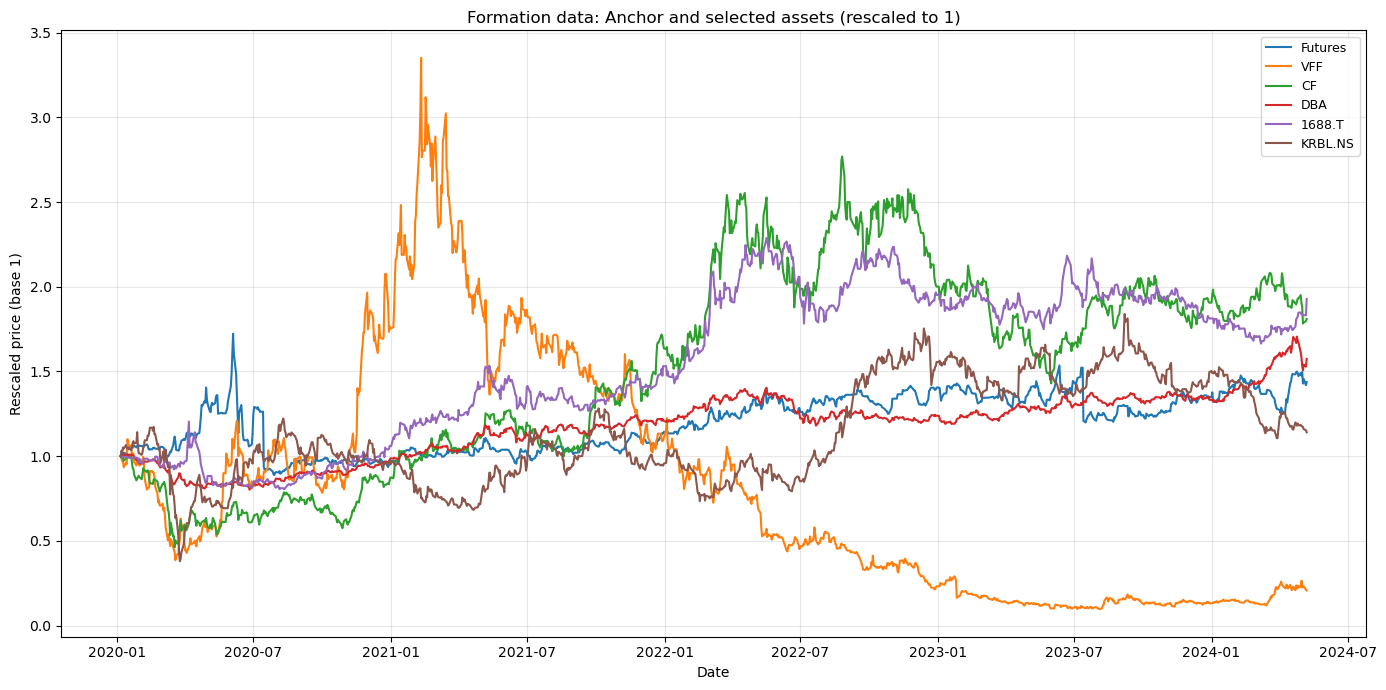

,Futures,VFF,CF,DBA,1688.T,KRBL.NS
Date,,,,,,
2020-01-06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2020-01-07,1.002342,0.987889,0.990870,1.002446,0.996997,1.032463
2020-01-08,1.002342,0.970588,0.995435,0.997554,0.996997,1.021514
2020-01-09,1.014832,0.970588,0.990652,1.000000,0.996997,1.050711
2020-01-10,1.020297,0.934256,0.973261,1.009174,0.993994,1.044756
...,...,...,...,...,...,...
2024-05-01,1.496487,0.230104,1.881734,1.532204,1.837538,1.176787
2024-05-02,1.428571,0.224913,1.782784,1.507139,1.832132,1.172001
2024-05-03,1.455894,0.231834,1.788093,1.540559,1.832132,1.159238


In [68]:
plot_rescaled_prices(formation_data, title="Formation data: Anchor and selected assets (rescaled to 1)")

## 5. Hist Analysis


## 8. Optimization step with Gurobi

### Objective
The ESILV instructions explicitly require a **Gurobi optimization** and a **market-neutral basket**.

We estimate each selected asset's beta relative to the rice futures anchor on the formation sample, then solve:

$$\min_w \sum_t \left(r^{A}_t - R_t w \right)^2 + \lambda\, w^\top \Sigma w$$


subject to:

$$\sum_i w_i = 1$$

$$\beta^\top w = 1$$

$$0 \le w_i \le \text{max\_weight}$$


### Interpretation
- \(r^A_t\): rice futures return
- \(R_t\): vector of selected asset returns
- \(w\): basket weights
- \(\Sigma\): covariance matrix of selected asset returns
- \(\beta^\top w = 1\): the synthetic basket has the same anchor beta, which enforces **market neutrality** in the spread trade.


In [ ]:

train_returns = compute_returns(train_final)
test_returns = compute_returns(test_final)

anchor_train_ret = train_returns[ANCHOR]
assets_train_ret = train_returns[participating_assets]

asset_betas = pd.Series({
    asset: estimate_beta_to_anchor(assets_train_ret[asset], anchor_train_ret)
    for asset in participating_assets
})

display(asset_betas.rename("beta_to_anchor").to_frame())

weights = optimize_market_neutral_basket(
    anchor_returns=anchor_train_ret,
    asset_returns=assets_train_ret,
    asset_betas=asset_betas,
    max_weight=MAX_WEIGHT,
    lambda_risk=LAMBDA_RISK
)

display(weights.rename("optimized_weight").to_frame())

print("Sum of optimized weights:", round(weights.sum(), 6))
print("Basket beta to anchor:", round((weights * asset_betas.loc[weights.index]).sum(), 6))


,beta_to_anchor
VFF,0.104585
CF,0.134626
DBA,0.048269
1688.T,0.034834


Restricted license - for non-production use only - expires 2027-11-29


RuntimeError: Gurobi did not find an optimal solution.


## 9. Spread construction

We now build:

1. the **optimized synthetic basket**,
2. the log-spread between the rice futures anchor and that basket,
3. the formation z-score statistics used for trading.

This directly follows the article's spread-based trading logic and the professor's log-price / z-score approach.


In [ ]:

basket_train = build_synthetic_basket(train_final[participating_assets], weights)
basket_test = build_synthetic_basket(test_final[participating_assets], weights)

spread_train = compute_spread(train_final[ANCHOR], basket_train)
spread_test = compute_spread(test_final[ANCHOR], basket_test)

mean_spread_train = spread_train.mean()
std_spread_train = spread_train.std(ddof=0)

z_train = (spread_train - mean_spread_train) / std_spread_train
z_test = (spread_test - mean_spread_train) / std_spread_train

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

spread_train.plot(ax=axes[0], title="Formation spread: log(Futures) - log(Synthetic Basket)")
axes[0].axhline(mean_spread_train, linestyle="--")
axes[0].set_ylabel("Spread")

z_train.plot(ax=axes[1], title="Formation z-score")
axes[1].axhline(0, linestyle="--")
axes[1].set_ylabel("z-score")

plt.tight_layout()
plt.show()



## 10. Threshold tuning on the formation sample

The article tunes the opening / closing thresholds on the formation data through a grid search.

### Important adaptation
In the article's original **crypto intraday** context, the best thresholds can be very high (for example 9 and 7 standard deviations).  
For **daily rice futures / equities / ETF** data, such thresholds are generally too extreme and would generate very few trades.

Therefore, here we keep the **same methodology** but adapt the search range to a realistic daily setting:

- `open_z` in {1.0, 1.5, 2.0, 2.5, 3.0}
- `close_z` in {0.0, 0.5, 1.0, 1.5}
- always with `close_z < open_z`

This is a justified methodological adaptation, not an arbitrary simplification.


In [ ]:

basket_train_ret = compute_returns(
    pd.concat([basket_train.rename("basket")], axis=1)
)["basket"]

threshold_grid = grid_search_thresholds(
    anchor_returns=anchor_train_ret,
    basket_returns=basket_train_ret,
    spread=spread_train,
    mean_spread=mean_spread_train,
    std_spread=std_spread_train,
    tx_cost=TX_COST
)

display(threshold_grid.head(10))

best_open_z = float(threshold_grid.iloc[0]["open_z"])
best_close_z = float(threshold_grid.iloc[0]["close_z"])

print("Best open threshold :", best_open_z)
print("Best close threshold:", best_close_z)



## 11. Out-of-sample backtest on the test period

Now the methodology is fully fixed:

- selected assets,
- optimized Gurobi weights,
- formation spread mean and standard deviation,
- tuned opening / closing thresholds.

The test sample is therefore a **true out-of-sample evaluation**.


In [ ]:

basket_test_ret = compute_returns(
    pd.concat([basket_test.rename("basket")], axis=1)
)["basket"]

backtest_test = backtest_mean_reversion(
    anchor_returns=test_returns[ANCHOR],
    basket_returns=basket_test_ret,
    spread=spread_test,
    mean_spread=mean_spread_train,
    std_spread=std_spread_train,
    open_z=best_open_z,
    close_z=best_close_z,
    tx_cost=TX_COST
)

display(backtest_test.head())
print("Number of trades on the test sample:", int(backtest_test["entry_flag"].sum()))


In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

backtest_test["zscore"].plot(ax=axes[0], title="Test z-score and trading thresholds")
axes[0].axhline(best_open_z, linestyle="--")
axes[0].axhline(-best_open_z, linestyle="--")
axes[0].axhline(best_close_z, linestyle=":")
axes[0].axhline(-best_close_z, linestyle=":")
axes[0].axhline(0, linestyle="--")
axes[0].set_ylabel("z-score")

backtest_test["position"].plot(ax=axes[1], title="Strategy position over time")
axes[1].set_ylabel("Position")

plt.tight_layout()
plt.show()



## 12. Benchmark construction

The ESILV instructions require a comparison with a **simple benchmark**.

We use two benchmarks:

1. **Buy & Hold Rice Futures**
2. **Equal-Weight Basket** of the selected assets

The first is the most natural anchor benchmark.  
The second checks whether the spread strategy adds value compared with a naive exposure to the chosen rice-related equities.


In [ ]:

equal_weight = pd.Series(1 / len(participating_assets), index=participating_assets)

eq_basket_test = build_synthetic_basket(test_final[participating_assets], equal_weight)
eq_basket_test_ret = compute_returns(pd.concat([eq_basket_test.rename("eq_basket")], axis=1))["eq_basket"]

strategy_ret = backtest_test["strategy_return"].copy()
bh_anchor_ret = test_returns[ANCHOR].copy()
eq_basket_ret = eq_basket_test_ret.copy()

comparison = pd.concat(
    [
        strategy_ret.rename("Optimized market-neutral strategy"),
        bh_anchor_ret.rename("Buy & Hold Futures"),
        eq_basket_ret.rename("Equal-weight basket")
    ],
    axis=1
).dropna()

display(comparison.head())


In [ ]:

equity_curves = (1 + comparison).cumprod()

equity_curves.plot(title="Out-of-sample cumulative performance")
plt.ylabel("Growth of 1 unit of capital")
plt.show()

drawdowns = equity_curves.div(equity_curves.cummax()).sub(1)
drawdowns.plot(title="Out-of-sample drawdowns")
plt.ylabel("Drawdown")
plt.show()



## 13. Performance summary


In [ ]:

metrics_table = pd.concat(
    [performance_metrics(comparison[col]).rename(col) for col in comparison.columns],
    axis=1
).T

display(metrics_table.style.format("{:.4f}"))

print("Test trades executed by the strategy:", int(backtest_test["entry_flag"].sum()))



## 14. Final tables to reuse in the written report

The next outputs are useful for the PDF report:

- selected assets,
- screening statistics,
- optimized weights,
- best thresholds,
- final out-of-sample metrics.


In [ ]:

final_selection_table = screen_df.loc[participating_assets].copy()
final_selection_table["optimized_weight"] = weights.loc[final_selection_table.index]
display(final_selection_table)

report_summary = pd.DataFrame({
    "Selected assets": [", ".join(participating_assets)],
    "Open threshold": [best_open_z],
    "Close threshold": [best_close_z],
    "Trades on test": [int(backtest_test["entry_flag"].sum())]
})

display(report_summary)
display(metrics_table)



## 15. Methodological discussion and limitations

### What is faithful to the article / professor's code?
This notebook preserves the core logic:

- **screening first**, trading second,
- focus on **correlation** and **cointegration**,
- use of **log-prices**,
- **z-score** trading signals,
- **transaction costs**,
- **optimization-based allocation** with **Gurobi**.

### What is adapted?
The original setting is crypto intraday.  
This notebook applies the same framework to a **daily rice** universe, which required the following adaptations:

1. **Daily rolling windows** instead of very short intraday windows.
2. A **synthetic basket** of rice-related equities / ETFs around the `Futures` anchor.
3. More realistic **daily threshold ranges** for z-score entries and exits.
4. A careful treatment of **missing values** due to different exchanges and calendars.

### Main limitations
1. **Mixed currencies**: the assets are not all converted into one common FX denomination.
2. **Data availability differs across assets**: some series start late or have many missing values.
3. **Static basket weights**: the optimized weights are estimated on the formation sample and then held fixed in the test sample.
4. **Single split**: a full walk-forward re-estimation could be explored in future work.
5. **Simple transaction cost model**: we use a flat 10 bps cost, which ignores slippage and market impact.

### Conclusion
If the strategy outperforms the two simple benchmarks on the out-of-sample test period with acceptable Sharpe ratio and drawdown, then the notebook provides a coherent and academically defensible implementation of **Trading Game #1** for the rice universe.


# A FAIRE
- ne pas faire la moyenne sur la cointegration rolling de la partie screening